# Multi-Session PCA with Train/Test Split

Testing the new train/test split functionality.

In [64]:
# Imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

# Import and reload modules
import importlib
import session_class
importlib.reload(session_class)
from session_class import Session

import multi_session_pca
importlib.reload(multi_session_pca)
from multi_session_pca import MultiSessionPCA

print("✓ Imports loaded successfully!")

✓ Imports loaded successfully!


## Initialize with Configuration

In [65]:
# Initialize with configuration
analyzer = MultiSessionPCA({
    'epok': [0, 350],
    'bin_size': 1,
    'smooth_ker_size': 25,
    'alignment_point': 'go_cue',
    'ssd_number': 2,
    'normalize': False,
    'delta': False,
    'subtract_average_PSTH': False,
    'n_pca_components': 5
})

print(f"is_split flag: {analyzer.is_split}")

is_split flag: False


## Load and Validate Data

In [66]:
# Load data
base_path = Path.cwd().parent / 'data' / 'unified_cell_trial_data'
pickle_file = base_path / 'msn_fiona_cell_trial_data.pkl'

analyzer.load_data(pickle_file)

Loading data from: /Users/barak/Projects/population_analysis/data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl
✓ Database loaded: 770,705 cell-trial combinations
  Total sessions: 60
  Total unique cells: 1414


In [67]:
# Validate sessions
analyzer.validate_all_sessions(verbose=False)
print(f"Valid sessions: {len(analyzer.valid_sessions)}")

✓ Session statistics computed for 60 sessions
  Excluded sessions: 1
  Candidate sessions: 59
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
Valid sessions: 40


## Extract PSTHs with Train/Test Split

**Key test**: Using `split_train_test=True` with 50/50 split and fixed random seed

In [68]:
# Extract with train/test split
sessions_PSTHs = analyzer.extract_all_sessions_parallel(
    split_train_test=True,
    test_fraction=0.5,
    random_state=42
)

print(f"\nis_split flag after extraction: {analyzer.is_split}")

Extracting PSTHs from 40 sessions using 6 workers...
  Using pre-loaded data (efficient mode)
  Train/test split: 50% train / 50% test
  Random state: 42
  Subtract average: False
--------------------------------------------------------------------------------
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.


Processing:   2%|▎         | 1/40 [00:02<01:39,  2.56s/it]

[1/40] ✓ fi211102a: 67 cells (dropped: SSD: train=2, test=2, alignment=4)


Processing:   5%|▌         | 2/40 [00:02<00:44,  1.18s/it]

[2/40] ✓ fi211026a: 70 cells (dropped: SSD: train=4, test=3, alignment=5)


...

Processing:  92%|█████████▎| 37/40 [00:12<00:00,  7.85it/s]

[36/40] ✓ fi210726a: 11 cells (train/test split)
[37/40] ✓ fi210721a: 12 cells (train/test split)
[38/40] ✓ fi210901a: 12 cells (train/test split)
[39/40] ✓ fi210815a: 11 cells (train/test split)


Processing: 100%|██████████| 40/40 [00:12<00:00,  3.10it/s]

[40/40] ✓ fi210809a: 10 cells (train/test split)


--------------------------------------------------------------------------------
✓ Extraction complete: 40/40 successful
  ⚠ Cell filtering:
    SSD filtering - Train: 37, Test: 36
    Train/test alignment: 65 cells dropped (4.9%)
  Cells retained: Train=1253, Test=1253

is_split flag after extraction: True


## Concatenate Sessions

Should create separate train and test matrices

In [69]:
analyzer.concatenate_sessions()

Concatenating PSTH matrices across sessions...
✓ Concatenation complete (train/test split):
  Train - GO Left: (1253, 350)
  Train - GO Right: (1253, 350)
  Train - STOP Left: (1253, 350)
  Train - STOP Right: (1253, 350)
  Test  - GO Left: (1253, 350)
  Test  - GO Right: (1253, 350)
  Test  - STOP Left: (1253, 350)
  Test  - STOP Right: (1253, 350)


## Verify Split Data

Check that we have both train and test matrices

In [70]:
print("Train matrices:")
print(f"  GO Left Train: {analyzer.combined_go_left_train.shape if analyzer.combined_go_left_train is not None else 'None'}")
print(f"  GO Right Train: {analyzer.combined_go_right_train.shape if analyzer.combined_go_right_train is not None else 'None'}")
print(f"  STOP Left Train: {analyzer.combined_stop_left_train.shape if analyzer.combined_stop_left_train is not None else 'None'}")
print(f"  STOP Right Train: {analyzer.combined_stop_right_train.shape if analyzer.combined_stop_right_train is not None else 'None'}")

print("\nTest matrices:")
print(f"  GO Left Test: {analyzer.combined_go_left_test.shape if analyzer.combined_go_left_test is not None else 'None'}")
print(f"  GO Right Test: {analyzer.combined_go_right_test.shape if analyzer.combined_go_right_test is not None else 'None'}")
print(f"  STOP Left Test: {analyzer.combined_stop_left_test.shape if analyzer.combined_stop_left_test is not None else 'None'}")
print(f"  STOP Right Test: {analyzer.combined_stop_right_test.shape if analyzer.combined_stop_right_test is not None else 'None'}")

print(f"\nTotal cells: {analyzer.n_cells}")

Train matrices:
  GO Left Train: (1253, 350)
  GO Right Train: (1253, 350)
  STOP Left Train: (1253, 350)
  STOP Right Train: (1253, 350)

Test matrices:
  GO Left Test: (1253, 350)
  GO Right Test: (1253, 350)
  STOP Left Test: (1253, 350)
  STOP Right Test: (1253, 350)

Total cells: 1253


## Fit PCA on TRAIN Data Only

In [71]:
analyzer.fit_pca(pca_type='PCA', subtract_average=True)

✓ PCA matrix prepared (TRAIN only): (1253, 700)
  (n_cells=1253, n_features=700)
Fitting PCA with 5 components...
✓ PCA fitted
  PC1: 43.24% variance
  PC2: 23.32% variance
  PC3: 11.87% variance
  PC4: 7.09% variance
  PC5: 4.10% variance
  Total: 89.63%


## Project Both Train and Test Data

In [72]:
analyzer.project_all_conditions()

Projecting all conditions onto PC space...
✓ Projections complete (train/test split):
  Train - GO Left: (5, 350)
  Train - GO Right: (5, 350)
  Train - STOP Left: (5, 350)
  Train - STOP Right: (5, 350)
  Test  - GO Left: (5, 350)
  Test  - GO Right: (5, 350)
  Test  - STOP Left: (5, 350)
  Test  - STOP Right: (5, 350)


## Verify Projections

Check that we have both train and test PC projections

In [73]:
print("Train PC projections:")
print(f"  GO Left PCs: {analyzer.go_left_PCs.shape if analyzer.go_left_PCs is not None else 'None'}")
print(f"  GO Right PCs: {analyzer.go_right_PCs.shape if analyzer.go_right_PCs is not None else 'None'}")
print(f"  STOP Left PCs: {analyzer.stop_left_PCs.shape if analyzer.stop_left_PCs is not None else 'None'}")
print(f"  STOP Right PCs: {analyzer.stop_right_PCs.shape if analyzer.stop_right_PCs is not None else 'None'}")

print("\nTest PC projections:")
print(f"  GO Left PCs Test: {analyzer.go_left_PCs_test.shape if analyzer.go_left_PCs_test is not None else 'None'}")
print(f"  GO Right PCs Test: {analyzer.go_right_PCs_test.shape if analyzer.go_right_PCs_test is not None else 'None'}")
print(f"  STOP Left PCs Test: {analyzer.stop_left_PCs_test.shape if analyzer.stop_left_PCs_test is not None else 'None'}")
print(f"  STOP Right PCs Test: {analyzer.stop_right_PCs_test.shape if analyzer.stop_right_PCs_test is not None else 'None'}")

Train PC projections:
  GO Left PCs: (5, 350)
  GO Right PCs: (5, 350)
  STOP Left PCs: (5, 350)
  STOP Right PCs: (5, 350)

Test PC projections:
  GO Left PCs Test: (5, 350)
  GO Right PCs Test: (5, 350)
  STOP Left PCs Test: (5, 350)
  STOP Right PCs Test: (5, 350)


## Visualize Train Data (3D)

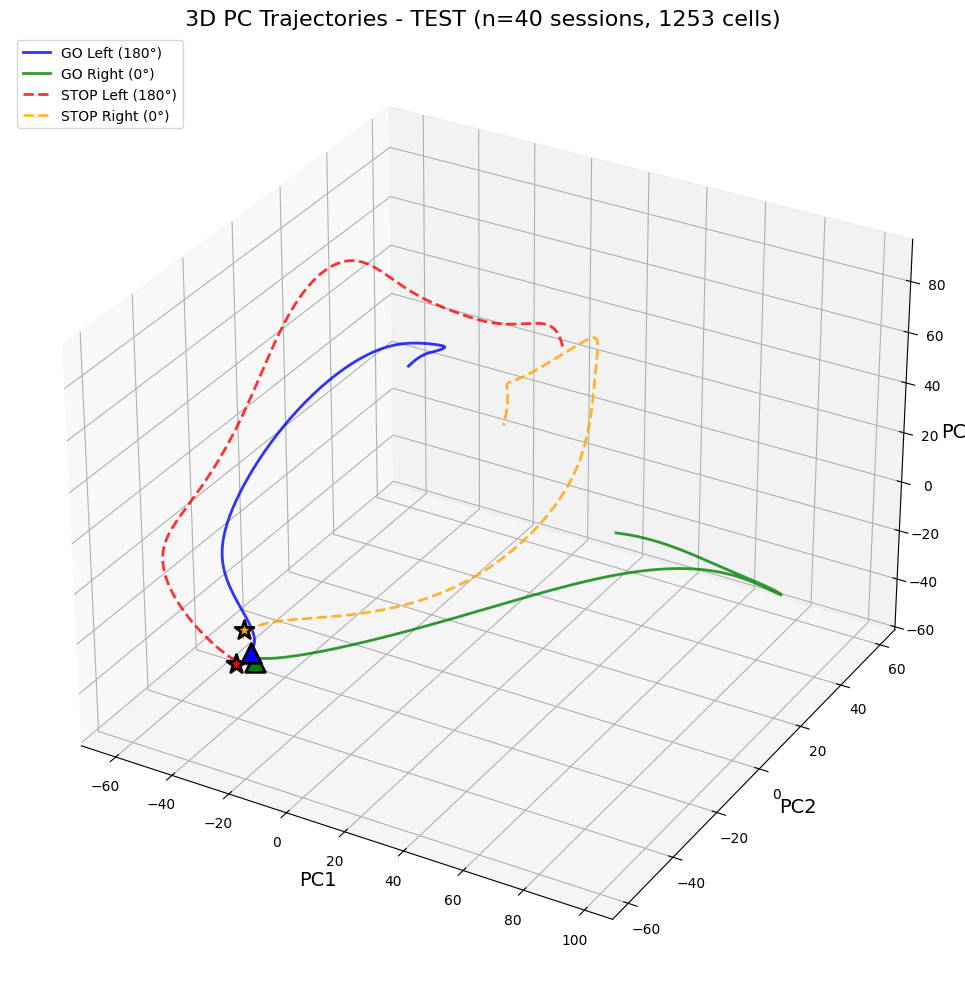

(<Figure size 1200x1000 with 1 Axes>,
 <Axes3D: title={'center': '3D PC Trajectories - TEST (n=40 sessions, 1253 cells)'}, xlabel='PC1', ylabel='PC2', zlabel='PC3'>)

In [74]:
# Plot 3D trajectory for TRAIN data
analyzer.plot_3d_trajectory(data_split='test')

## Visualize Test Data (3D)

Use the built-in plotting method with data_split='test'

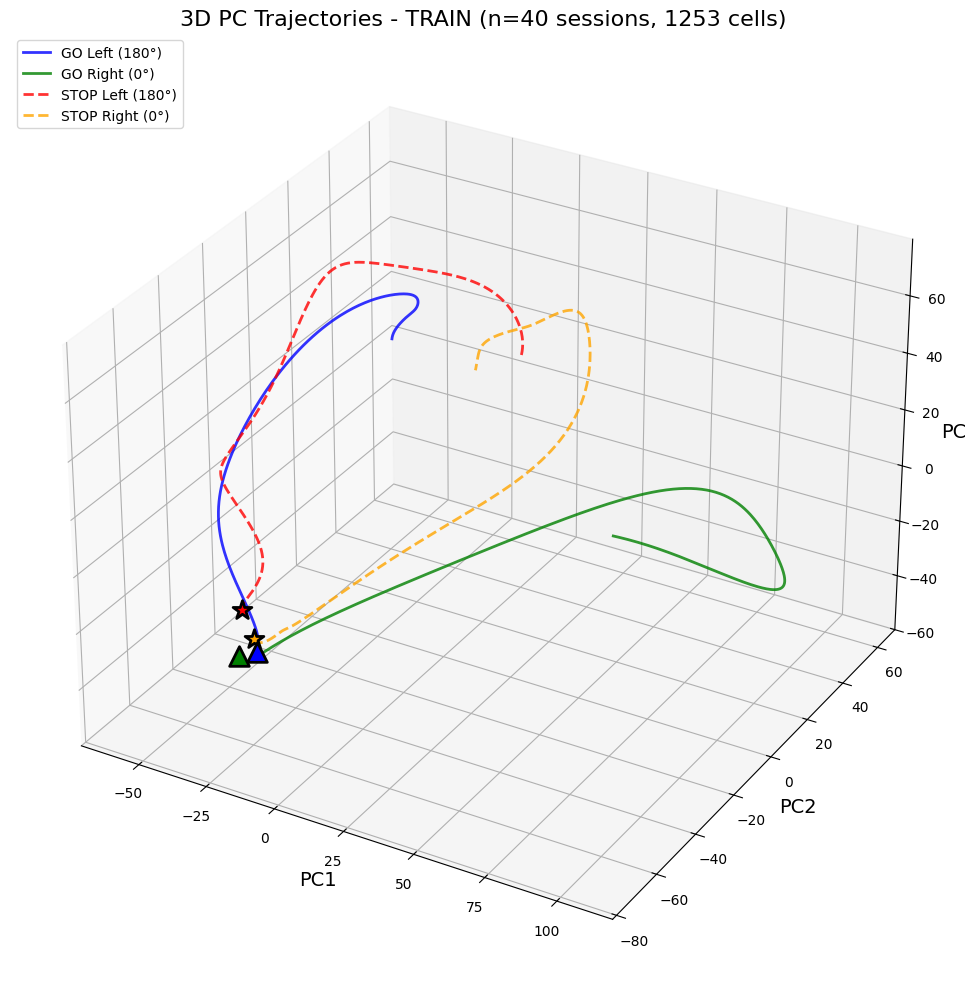

(<Figure size 1200x1000 with 1 Axes>,
 <Axes3D: title={'center': '3D PC Trajectories - TRAIN (n=40 sessions, 1253 cells)'}, xlabel='PC1', ylabel='PC2', zlabel='PC3'>)

In [75]:
# Plot 3D trajectory for TEST data using built-in method
analyzer.plot_3d_trajectory(data_split='train')

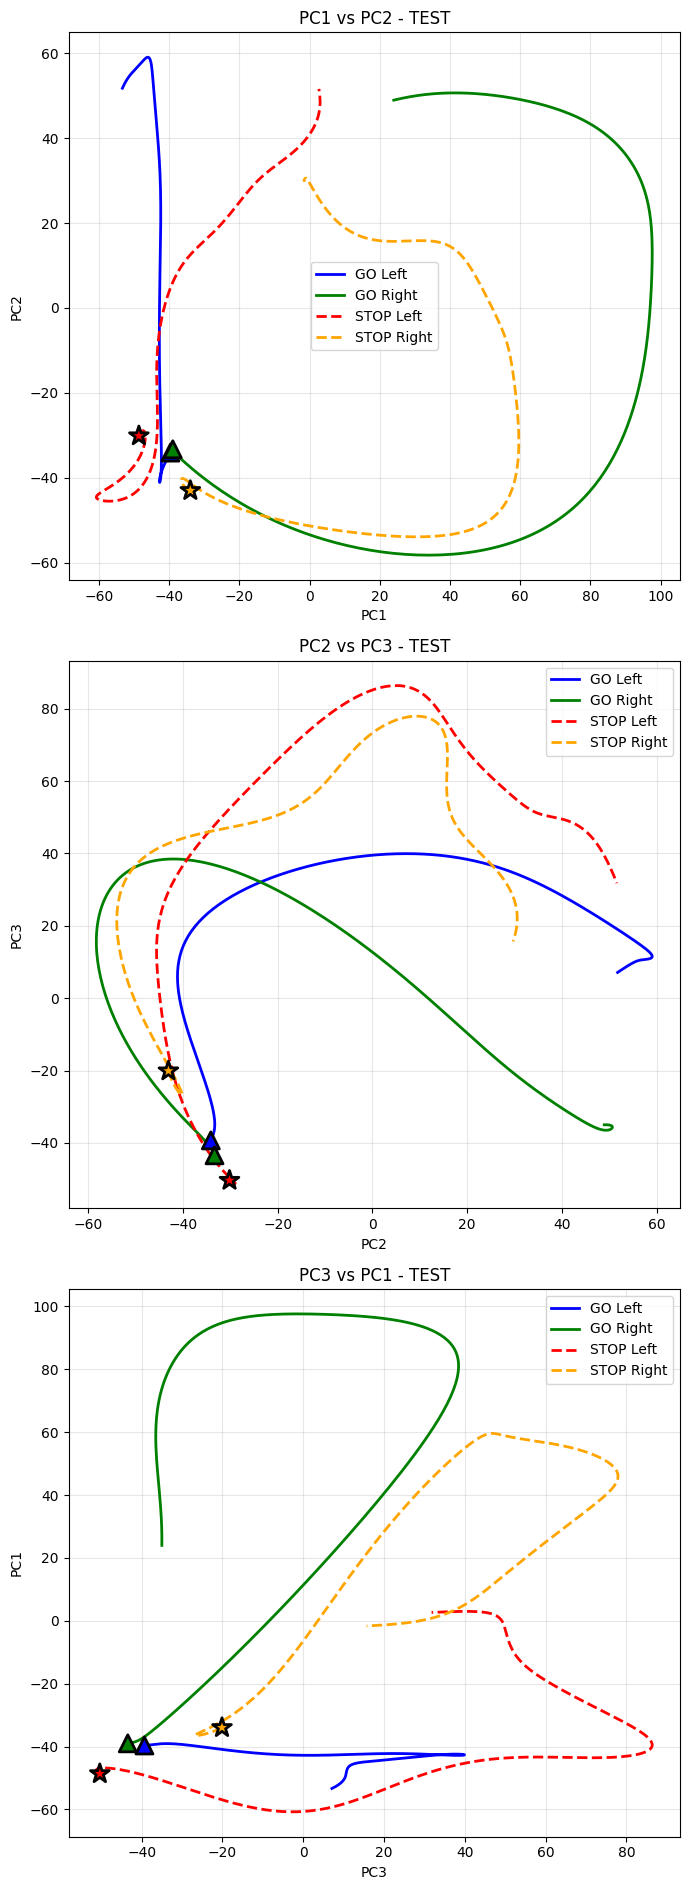

(<Figure size 700x1900 with 3 Axes>,
 array([<Axes: title={'center': 'PC1 vs PC2 - TEST'}, xlabel='PC1', ylabel='PC2'>,
        <Axes: title={'center': 'PC2 vs PC3 - TEST'}, xlabel='PC2', ylabel='PC3'>,
        <Axes: title={'center': 'PC3 vs PC1 - TEST'}, xlabel='PC3', ylabel='PC1'>],
       dtype=object))

In [76]:
analyzer.plot_2d_grid(data_split='test')

## Compare Train vs Test PC Trajectories

Plot PC timeseries for both train and test to see similarity

TRAIN data:


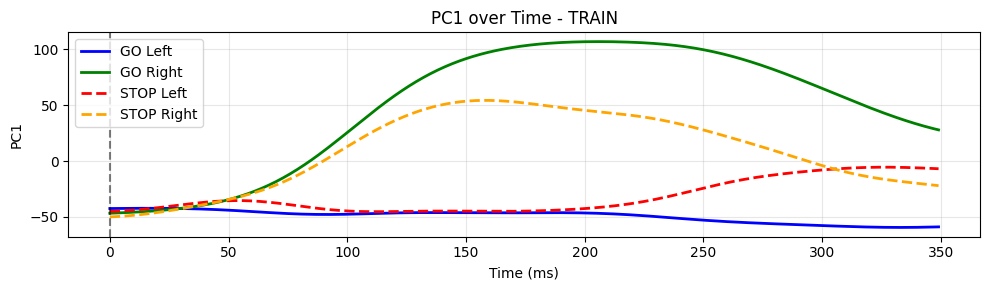


TEST data:


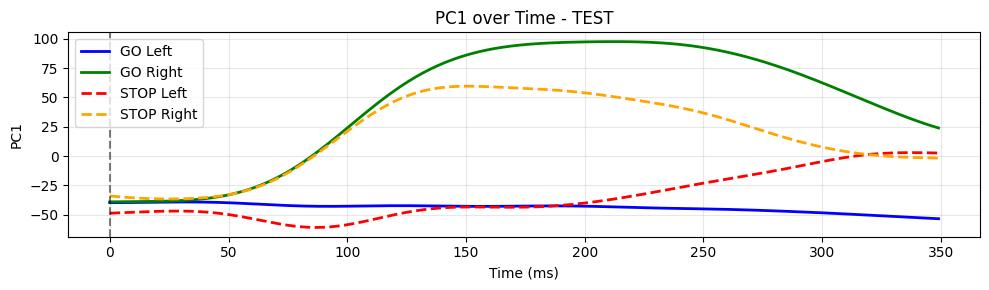

TRAIN data:


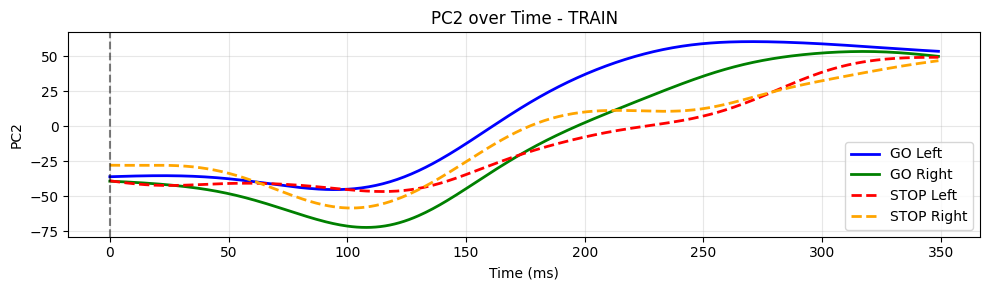


TEST data:


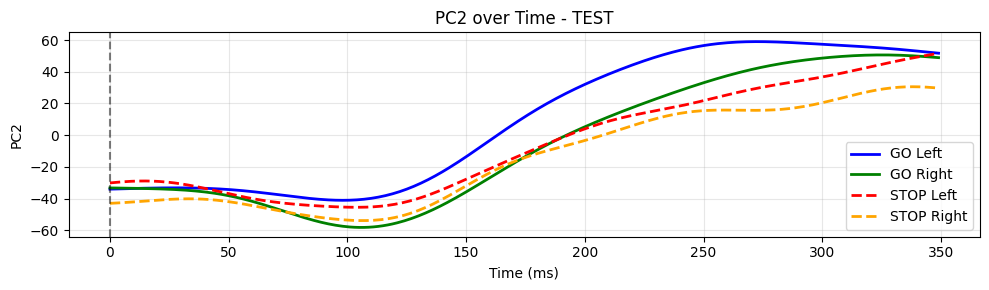

TRAIN data:


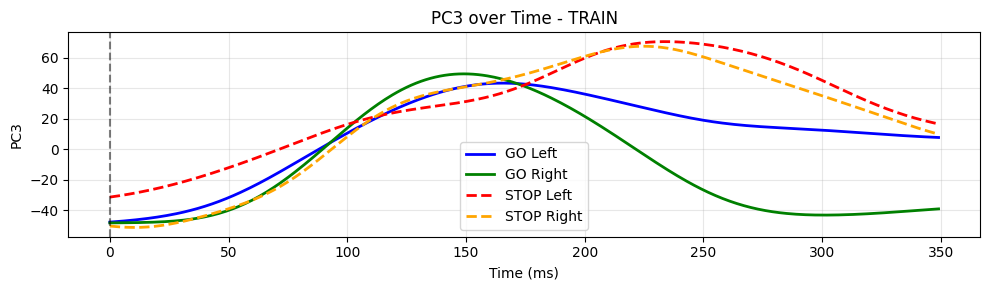


TEST data:


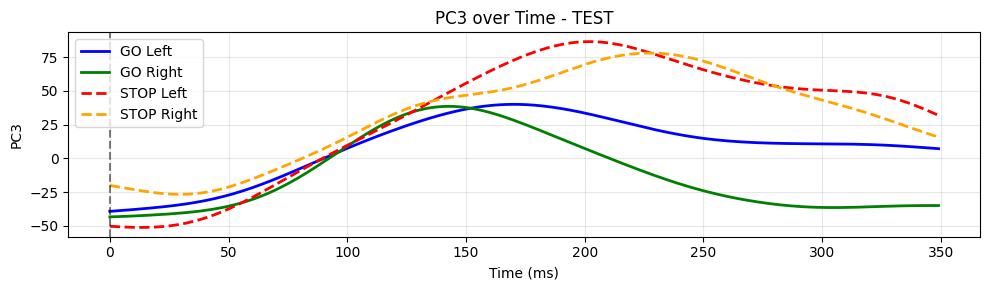


If train/test split is working correctly, the trajectories should be similar but not identical.


In [77]:
for i in range(3):
    print("TRAIN data:")
    analyzer.plot_pc_timeseries(pcs_to_plot=[i], data_split='train')

    print("\nTEST data:")
    analyzer.plot_pc_timeseries(pcs_to_plot=[i], data_split='test')

print("\nIf train/test split is working correctly, the trajectories should be similar but not identical.")

## Test Summary

Verify key functionality

In [78]:
print("=" * 80)
print("TRAIN/TEST SPLIT FUNCTIONALITY TEST")
print("=" * 80)

print(f"\n✓ Split flag set: {analyzer.is_split}")
print(f"✓ Train matrices created: {analyzer.combined_go_left_train is not None}")
print(f"✓ Test matrices created: {analyzer.combined_go_left_test is not None}")
print(f"✓ PCA fitted on train data")
print(f"✓ Train projections created: {analyzer.go_left_PCs is not None}")
print(f"✓ Test projections created: {analyzer.go_left_PCs_test is not None}")

print(f"\nData shapes:")
print(f"  Train GO matrix: {analyzer.combined_go_left_train.shape}")
print(f"  Test GO matrix: {analyzer.combined_go_left_test.shape}")
print(f"  Train PC projection: {analyzer.go_left_PCs.shape}")
print(f"  Test PC projection: {analyzer.go_left_PCs_test.shape}")

print(f"\nPCA variance explained:")
for i, var in enumerate(analyzer.pca.explained_variance_ratio_, 1):
    print(f"  PC{i}: {var*100:.2f}%")
print(f"  Total: {analyzer.pca.explained_variance_ratio_.sum()*100:.2f}%")

print("\n" + "=" * 80)
print("ALL TESTS PASSED!")
print("=" * 80)

TRAIN/TEST SPLIT FUNCTIONALITY TEST

✓ Split flag set: True
✓ Train matrices created: True
✓ Test matrices created: True
✓ PCA fitted on train data
✓ Train projections created: True
✓ Test projections created: True

Data shapes:
  Train GO matrix: (1253, 350)
  Test GO matrix: (1253, 350)
  Train PC projection: (5, 350)
  Test PC projection: (5, 350)

PCA variance explained:
  PC1: 43.24%
  PC2: 23.32%
  PC3: 11.87%
  PC4: 7.09%
  PC5: 4.10%
  Total: 89.63%

ALL TESTS PASSED!
